# Plastic zone at a Mode III crack tip

This notebook derives, symbolically, the size and shape of the first-order
plastic-zone estimate at the tip of a Mode III crack using the von Mises
yield criterion.

Run it however is easiest for you:

- **In a browser, nothing installed:**
  https://cfni-dtu.github.io/41526-notebooks/lab/index.html?path=lecture03/ModeIII_plastic_zone.ipynb
- **Locally**, with any Jupyter install
  (`pip install numpy matplotlib sympy jupyterlab`, then `jupyter lab`).

See also the companion notebook for the **Mode I** case
(`../lecture04/ModeI_plastic_zone.ipynb`), which compares directly against
the result derived here.


In [1]:
# Works both in a normal Jupyter kernel (sympy already installed)
# and in JupyterLite's Pyodide kernel (sympy fetched on the fly via micropip).
try:
    import sympy as sp
except ImportError:
    import micropip
    await micropip.install("sympy")
    import sympy as sp

import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message=".*width parameter as float.*")  # harmless mpl deprecation

sp.init_printing()


## Step 1 — Mode III near-tip stress field

Ahead of a Mode III (anti-plane shear) crack tip, the non-zero polar stress
components are

$$
\sigma_{rz} = \frac{K_{III}}{\sqrt{2\pi r}}\sin\frac{\theta}{2}, \qquad
\sigma_{\theta z} = \frac{K_{III}}{\sqrt{2\pi r}}\cos\frac{\theta}{2},
$$

with all other stress components zero.


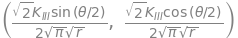

In [2]:
K3, r, theta, sigma_Y = sp.symbols('K_III r theta sigma_Y', positive=True, real=True)

sigma_rz = K3/sp.sqrt(2*sp.pi*r) * sp.sin(theta/2)
sigma_tz = K3/sp.sqrt(2*sp.pi*r) * sp.cos(theta/2)

sigma_rz, sigma_tz


## Step 2 — von Mises equivalent stress

With only $\sigma_{rz}$ and $\sigma_{\theta z}$ non-zero, $\sigma_{kk}=0$, so
$s_{ij}=\sigma_{ij}$ and

$$
\sigma_e^2 = \tfrac32\, s_{ij}s_{ij} = 3\left(\sigma_{rz}^2+\sigma_{\theta z}^2\right).
$$


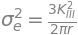

In [3]:
sigma_e2 = sp.simplify(3*(sigma_rz**2 + sigma_tz**2))
display(sp.Eq(sp.Symbol('sigma_e^2'), sigma_e2))


Notice that $\sin^2(\theta/2)+\cos^2(\theta/2)=1$ removes all $\theta$
dependence — a first hint that the Mode III plastic zone will turn out to be
a **circle**.

## Step 3 — Solve $\sigma_e=\sigma_Y$ for $r=r_p$


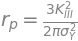

In [4]:
rp = sp.solve(sp.Eq(sigma_e2, sigma_Y**2), r)[0]
rp = sp.simplify(rp)
display(sp.Eq(sp.Symbol('r_p'), rp))


## Step 4 — Plot the shape

Since $r_p$ does not depend on $\theta$, the plastic zone is an exact circle
centered at the crack tip. We plot it normalised by $(K/\sigma_Y)^2$,
alongside the **Mode I** plane-stress and plane-strain results from Lecture
4 for direct comparison.


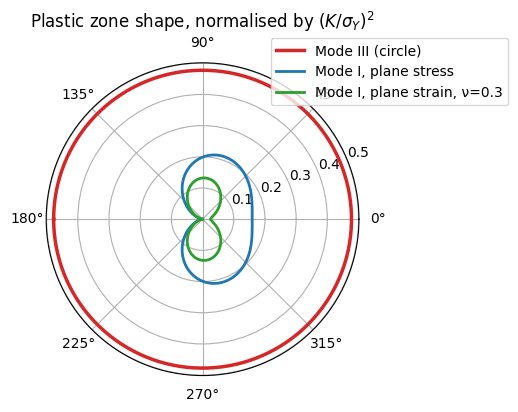

In [5]:
nu = sp.symbols('nu', positive=True)
rp_mode1_stress = (1/(4*sp.pi))*(1 + sp.cos(theta) + sp.Rational(3, 2)*sp.sin(theta)**2)
rp_mode1_strain = (1/(4*sp.pi))*((1 - 2*nu)**2*(1 + sp.cos(theta)) + sp.Rational(3, 2)*sp.sin(theta)**2)

rp_mode1_stress_f = sp.lambdify(theta, rp_mode1_stress, 'numpy')
rp_mode1_strain_f = sp.lambdify((theta, nu), rp_mode1_strain, 'numpy')

th = np.linspace(-np.pi, np.pi, 400)
r_mode3 = np.full_like(th, float(rp.subs({K3: 1, sigma_Y: 1})))

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))
ax.plot(th, r_mode3, lw=2.5, color='tab:red', label='Mode III (circle)')
ax.plot(th, rp_mode1_stress_f(th), lw=2, color='tab:blue', label='Mode I, plane stress')
ax.plot(th, rp_mode1_strain_f(th, 0.3), lw=2, color='tab:green', label='Mode I, plane strain, ν=0.3')
ax.set_title(r'Plastic zone shape, normalised by $(K/\sigma_Y)^2$')
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1))
fig.tight_layout()
plt.show()


## Takeaways

- The Mode III plastic zone is an exact **circle** of radius
  $r_p=\tfrac{3}{2\pi}(K_{III}/\sigma_Y)^2$: the two non-zero shear stress
  components combine into a von Mises stress that happens to be
  independent of $\theta$.
- This is noticeably larger than the Mode I plane-strain zone directly
  ahead of the tip, and comparable in overall extent to the Mode I
  plane-stress zone — see the companion Mode I notebook for why the
  Mode I zone is lobed instead of circular.
- As always, this is only a **first-order estimate**: it assumes the
  elastic $K$-field remains valid right up to the elastic-plastic boundary.
